# 36. Magnetocrystalline anisotropy

Which way a magnet wants to point. Cobalt in a stretched tetragonal cell prefers
its long axis, and the energy difference between pointing along that axis and
lying in the basal plane is what makes a hard magnet hard, what pins a spiral
into a plane, and what a recording medium is made of.

That energy is small: about a milli-electronvolt here, against a total energy of
seventy-four Rydberg. Taking it as a difference of two separately converged
calculations asks them to agree in their ninth digit. The **force theorem** does
not ask that. Converge the magnet with no spin-orbit coupling, turn the
converged density so its magnetization points where you want, and diagonalise
**once** with the coupling switched on. Nothing is re-converged, and the
anisotropy is the difference of the two sums of occupied energies.

On a three-layer cobalt film this gives **0.3458 meV** where `pw.x` gives
**0.3532 meV**.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from defumat import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

scalar = Calculator.from_file(CASES / "co-tetragonal-anisotropy-sr.in", PSEUDO,
                              announce=False)
spinor = Calculator.from_file(CASES / "co-tetragonal-anisotropy-soc.in", PSEUDO,
                              announce=False)

mae = scalar.get_anisotropy(spinor, directions="xz")
print(f"easy axis {mae.easy_axis}, anisotropy {mae.anisotropy_mev:.4f} meV")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


easy axis (0.0, 0.0, 1.0), anisotropy 1.2352 meV


The easy axis comes out along `c`, and the crystal pays about a
milli-electronvolt to lie in the basal plane instead.

## Why it has to be a diagonalisation

The tempting shortcut is to freeze the wavefunctions as well and simply take the
expectation value of the spin-orbit term once. That returns **zero**, for a
reason worth knowing: spin-orbit coupling first appears as the orbital moment
dotted into the spin direction, and in a magnet without spin-orbit coupling the
orbital moment is quenched by the crystal field. There is nothing for the spin
direction to talk to.

The anisotropy is second order in the coupling. What produces it is the
repulsion between levels that the coupling causes, and only a diagonalisation
sees that.

In [2]:
from defumat.units import RY_TO_EV

first = [scalar.get_first_order_soc(spinor, direction=d) * RY_TO_EV * 1000
         for d in [(1, 0, 0), (0, 0, 1)]]
print(f"first order, in-plane and along c: {first[0]:+.6f}, {first[1]:+.6f} meV")
print(f"force theorem on the same density: {mae.anisotropy_mev:.6f} meV")

first order, in-plane and along c: -0.000001, +0.000002 meV
force theorem on the same density: 1.235151 meV


## The control: switch the coupling off

Without spin-orbit coupling the energy cannot depend on the moment's direction
at all, because nothing connects spin to the lattice. That is not an
approximation, it is a symmetry, and it makes a sharp test: the same calculation
with the coupling switched off inside the same pseudopotential must give a flat
line.

In [3]:
angles = [0, 30, 60, 90]
directions = [(np.sin(np.radians(a)), 0, np.cos(np.radians(a))) for a in angles]

curves = {}
for coupling in (1.0, 0.0):
    scan = scalar.get_anisotropy(spinor, directions=directions, soc_scale=coupling)
    curves[coupling] = scan.energies_mev
    print(f"coupling {coupling:.0f}: spread {scan.anisotropy_mev:.3e} meV")

coupling 1: spread 1.235e+00 meV


coupling 0: spread 1.933e-08 meV


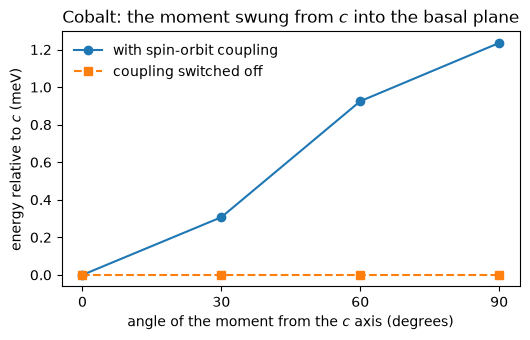

In [4]:
fig, ax = plt.subplots(figsize=(5.4, 3.5))
ax.plot(angles, curves[1.0], "o-", label="with spin-orbit coupling")
ax.plot(angles, curves[0.0], "s--", label="coupling switched off")
ax.set_xlabel("angle of the moment from the $c$ axis (degrees)")
ax.set_ylabel("energy relative to $c$ (meV)")
ax.set_title("Cobalt: the moment swung from $c$ into the basal plane")
ax.set_xticks(angles)
ax.legend(frameon=False)
fig.tight_layout()

The flat line is the whole content of the theorem. Everything that makes the
other curve bend comes from the spin-orbit term, and switching it off recovers a
crystal that does not know which way its moment points.


## The same number from one angle

Taking the anisotropy as a difference of two energies throws away most of the
precision: it is a milli-electronvolt out of a hundred Rydberg, so the two
numbers agree in seven digits before they disagree in the eighth. The **torque**
avoids that entirely. For `E(theta) = K sin^2(theta)` the slope at 45 degrees is
`K` itself, so one calculation gives the constant with nothing cancelling.

It also behaves better at a broad smearing. The torque is the slope of the
*free* energy, and in a metal the entropy carries a real part of the angle
dependence: at the smearing used here the plain band-energy difference is more
than twice the converged answer, while the torque is within a few per cent of
it.

In [5]:
torque = scalar.get_torque(spinor)

print(f"K from the torque at 45 deg      {torque.anisotropy_constant_mev:+.4f} meV")
print(f"K from the free-energy difference {mae.free_anisotropy_mev:+.4f} meV")
print(f"K from the band-energy difference {mae.anisotropy_mev:+.4f} meV")

K from the torque at 45 deg      +0.5523 meV
K from the free-energy difference +0.5522 meV
K from the band-energy difference +1.2352 meV


## Against Quantum ESPRESSO

Measured separately on the three-layer cobalt film of QE's own force-theorem
example, in-plane against out-of-plane:

| | this code | `pw.x` |
|---|---|---|
| band energy, in-plane | -75.257861 eV | -75.504327 eV |
| band energy, out-of-plane | -75.258207 eV | -75.504680 eV |
| **anisotropy** | **0.3458 meV** | **0.3532 meV** |

The two band energies are each offset by the same amount, because that film's
density is harder to converge here than in `pw.x`. A shift common to both
directions cancels in the difference, which is exactly what a theorem at frozen
density promises.



## The other route: let the density relax

The theorem above holds the density still. That is what makes it precise, and it
is also what it leaves out: in a real magnet the electrons rearrange when the
moment turns, and that rearrangement lowers the energy by a little in every
direction. The anisotropy is then a difference of two such gains.

The other way to compute it is the obvious one. Converge a complete calculation
with the moment along each direction and subtract the two total energies. It
costs one self consistent run per direction instead of one diagonalisation, and
it asks two numbers near 74 Rydberg to be trusted in their eighth decimal.


In [6]:
relaxed_cell = Calculator.from_file(CASES / "co-tetragonal-relaxed-mae.in",
                                    PSEUDO, announce=False)
relaxed = relaxed_cell.get_relaxed_anisotropy(directions="xz")

print(f"frozen density, band energy   {mae.anisotropy_mev:.4f} meV")
print(f"frozen density, free energy   {mae.free_anisotropy_mev:.4f} meV")
print(f"relaxed density               {relaxed.anisotropy_mev:.4f} meV")
print(f"easy axis {relaxed.easy_axis}, moments ended "
      f"{relaxed.drifts.max():.3f} degrees from where they started")


frozen density, band energy   1.2352 meV
frozen density, free energy   0.5522 meV
relaxed density               0.4473 meV
easy axis (0.0, 0.0, 1.0), moments ended 0.000 degrees from where they started


Three numbers, and which two should be compared is the whole of this cell.

This is a metal with a smearing, so its electrons are described by a free energy
rather than by a sum of occupied levels: the entropy of the partially filled
states near the Fermi level is part of the energy, and it changes when the moment
turns. The band sum leaves that out. On this crystal at this smearing it is worth
more than half the answer, which is why the first two lines differ by a factor of
about two rather than by a little.

The comparison to make is therefore the **second** line against the **third**,
and those agree to about twenty per cent. What separates them is real physics
rather than arithmetic: the frozen calculation does not let the electrons
rearrange when the moment turns, and the relaxed one does. That rearrangement
lowers the energy in both directions, and the part of it that does not cancel is
the difference between the two lines.

**How far can the relaxed number be trusted?** Switch the spin orbit coupling off
and every direction must give the same energy, because nothing is then left to
tell the crystal apart from its own rotations. On this cell that difference does
not fall below about 0.011 meV however tightly the calculation is converged: two
runs started from two different densities stop at two slightly different places,
and no threshold closes the gap. So the relaxed route here is meaningful down to
about a hundredth of a milli electron volt, which is forty times smaller than the
anisotropy and ten times smaller than the gap between the two routes. The frozen
route has no such floor, because everything except the band energy cancels
between the two directions before any subtraction happens.

**What the relaxed route buys.** Nothing is handed from one calculation to
another, so the restrictions that came from that handoff are gone. A PAW dataset
works, and tetragonal nickel with a fully relativistic PAW potential is a
calculation the frozen route cannot do at all. So does a Hubbard `U`.

**What it costs, besides time.** Nothing holds the moment while the density
relaxes, so a direction that the symmetry of the crystal does not hold in place
can end up somewhere else, and the energy then belongs to a state that was not
the one asked for. Both directions here are fixed by symmetry and do not move,
which is what the last line above checks.


## What it will not do

The frozen route cannot take a PAW dataset, a Hubbard `U` or a meta-GGA, because
only the density is handed from the first calculation to the second and those
need more than a density. The relaxed route above takes the first two, since it
hands nothing over.

Neither takes an applied magnetic field, whose energy sits outside the reported
total, or a spin spiral, which has no spin orbit coupling to switch on.

The numbers quoted against `pw.x`, the checks behind the flat line, and the
measurement of the floor described above live in
`tests/regression/test_anisotropy.py` and
`tests/regression/test_relaxed_anisotropy.py`.
